In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import warnings
warnings.filterwarnings('ignore') 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from scipy.optimize import minimize

from datasets import circle, plot_circle, diamond, plot_diamond, wavy_lines, plot_wavy
import single_qubit
from single_qubit import *
import importlib
importlib.reload(single_qubit)
import plotting
from plotting import *
importlib.reload(plotting)

<module 'plotting' from '/home/elena_niero/Documents/Master/second_sem/LCP-B/LCP_modB/Project/plotting.py'>

# Circle

In [14]:
all_losses_circle = {}
all_train_accuracies_circle = {}
all_test_accuracies_circle = {}

In [15]:
data, (centers, radii) = circle(samples=4200, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.95,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [16]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)


[[3.13553675 5.85300733 3.66518877]] [[0.53838419 0.45448273 0.20928776]] [0.00371966 0.24150623]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 76.722227
Iteration 2, cost: 74.246969
Iteration 3, cost: 72.306800
Iteration 4, cost: 71.250837
Iteration 5, cost: 68.852227
Iteration 6, cost: 66.988610
Iteration 7, cost: 65.359248
Iteration 8, cost: 63.146509
Iteration 9, cost: 61.846771
Iteration 10, cost: 61.841987
Iteration 11, cost: 61.841948
Iteration 12, cost: 61.841933
Iteration 13, cost: 61.841933
Iteration 14, cost: 61.841933
Iteration 15, cost: 61.841933
[[3.32009461 5.85300634 3.66518958]] [[0.30489727 3.25367633 0.20928776]]
Optimization success: True
Final cost: 61.841933
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [17]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7338


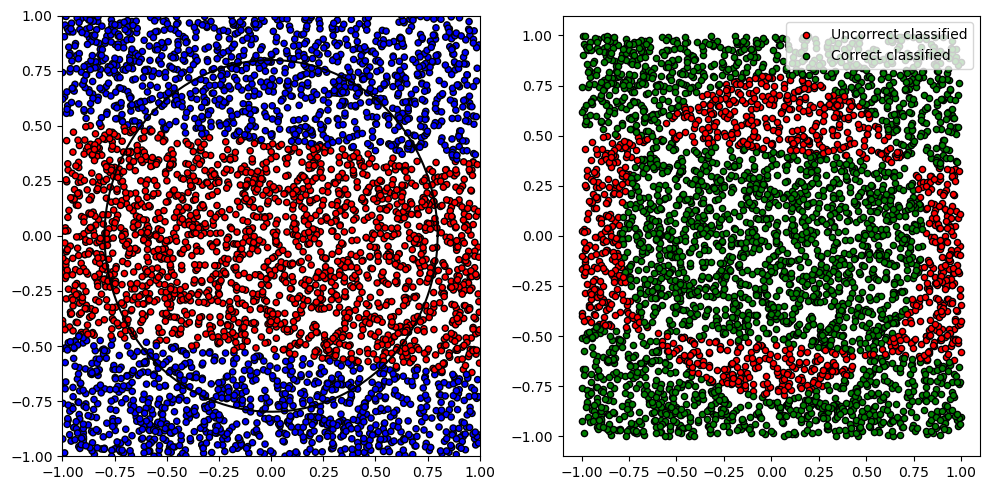

In [18]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

fig, ax = plt.subplots(1,2, figsize =(10,5 ))
theta_circle = np.linspace(0, 2*np.pi, 500)
r = np.sqrt(2/np.pi)
ax[0].plot(r*np.cos(theta_circle), r*np.sin(theta_circle),'k-', label = 'True circle')
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)

ax[0].scatter(x_test[:, 0], x_test[:, 1], c= preds, cmap='bwr', edgecolors='k',s=20)

labels = []
for i in range(len(x_test)):
    if preds[i] == y_test[i]:
        label = 'Correct classified' if 'Correct classified' not in labels else None
        ax[1].scatter(x_test[i, 0], x_test[i, 1], c= 'g', edgecolors='k',s=20, label= label)
        labels.append(label)
    else:
        label = 'Uncorrect classified' if 'Uncorrect classified' not in labels else None
        ax[1].scatter(x_test[i, 0], x_test[i, 1], c= 'r', edgecolors='k',s=20, label= label)
        labels.append(label)
        
ax[1].legend()
plt.tight_layout()
plt.show()

### 2 layers

In [19]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[3.20268514 2.38735879 2.8179158 ]
 [6.16159448 2.20082621 2.8411492 ]] [[0.13351555 0.04795773 0.77540951]
 [0.57068318 0.76070481 0.1498628 ]] [0.57182877 0.25364247]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 81.492985
Iteration 2, cost: 76.120475
Iteration 3, cost: 70.285338
Iteration 4, cost: 68.126859
Iteration 5, cost: 66.705450
Iteration 6, cost: 65.931922
Iteration 7, cost: 64.103737
Iteration 8, cost: 62.244911
Iteration 9, cost: 60.779201
Iteration 10, cost: 60.534241
Iteration 11, cost: 60.403964
Iteration 12, cost: 60.333772
Iteration 13, cost: 60.264951
Iteration 14, cost: 60.245137
Iteration 15, cost: 60.230759
Iteration 16, cost: 60.229608
Iteration 17, cost: 60.229117
Iteration 18, cost: 60.229092
Iteration 19, cost: 60.229091
Iteration 20, cost: 60.229091
Iteration 21, cost: 60.229091
Iteration 22, cost: 60.229091
Iteration 23, cost: 60.229091
[[3.22122507 3.00546749 2.81791514]
 [6.43123024 2.20082624 3.45925857]] [[ 0.01607895 -0.35417055  0.77540951]
 [

In [20]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7439


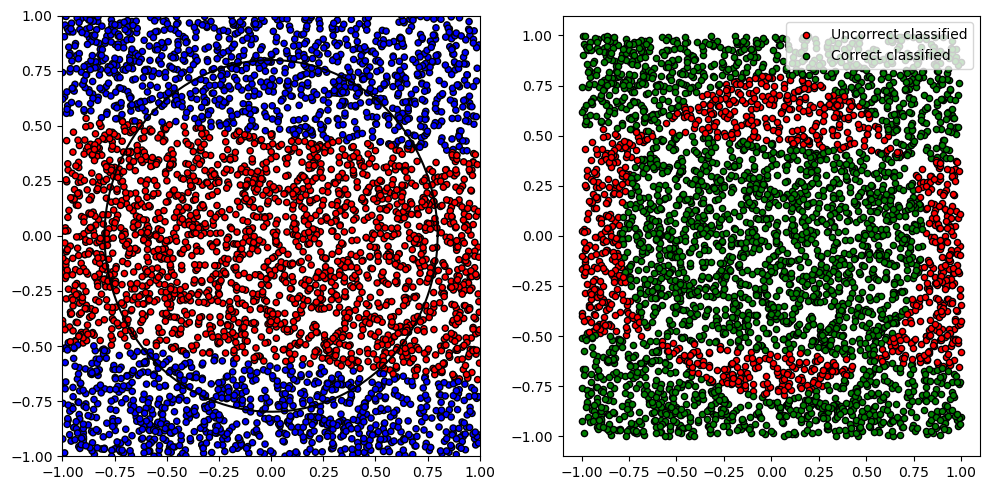

In [21]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

fig, ax = plt.subplots(1,2, figsize =(10,5 ))
theta_circle = np.linspace(0, 2*np.pi, 500)
r = np.sqrt(2/np.pi)
ax[0].plot(r*np.cos(theta_circle), r*np.sin(theta_circle),'k-', label = 'True circle')
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)

ax[0].scatter(x_test[:, 0], x_test[:, 1], c= preds, cmap='bwr', edgecolors='k',s=20)

labels = []
for i in range(len(x_test)):
    if preds[i] == y_test[i]:
        label = 'Correct classified' if 'Correct classified' not in labels else None
        ax[1].scatter(x_test[i, 0], x_test[i, 1], c= 'g', edgecolors='k',s=20, label= label)
        labels.append(label)
    else:
        label = 'Uncorrect classified' if 'Uncorrect classified' not in labels else None
        ax[1].scatter(x_test[i, 0], x_test[i, 1], c= 'r', edgecolors='k',s=20, label= label)
        labels.append(label)
        
ax[1].legend()
plt.tight_layout()
plt.show()

### 4 layers

In [22]:
# 16 mins
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[1.43295466 0.07242008 0.81895492]
 [1.94318885 0.73437091 6.19433127]
 [1.93919612 0.81884951 1.25087106]
 [3.69264829 0.40239733 5.41883345]] [[0.96149968 0.24674742 0.45009527]
 [0.02213445 0.64071022 0.41392606]
 [0.27005847 0.20683711 0.65402308]
 [0.41621703 0.17965929 0.68910908]] [0.56507228 0.85867205]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 73.674446
Iteration 2, cost: 72.833657
Iteration 3, cost: 70.947309
Iteration 4, cost: 70.192200
Iteration 5, cost: 68.780149
Iteration 6, cost: 66.164385
Iteration 7, cost: 63.011064
Iteration 8, cost: 62.563908
Iteration 9, cost: 62.446510
Iteration 10, cost: 62.319878
Iteration 11, cost: 62.172084
Iteration 12, cost: 62.127820
Iteration 13, cost: 62.091063
Iteration 14, cost: 62.028235
Iteration 15, cost: 62.003962
Iteration 16, cost: 61.986809
Iteration 17, cost: 61.960025
Iteration 18, cost: 61.934068
Iteration 19, cost: 61.889613
Iteration 20, cost: 61.872421
Iteration 21, cost: 61.859577
Iteration 22, cost: 61.841639


In [23]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7867


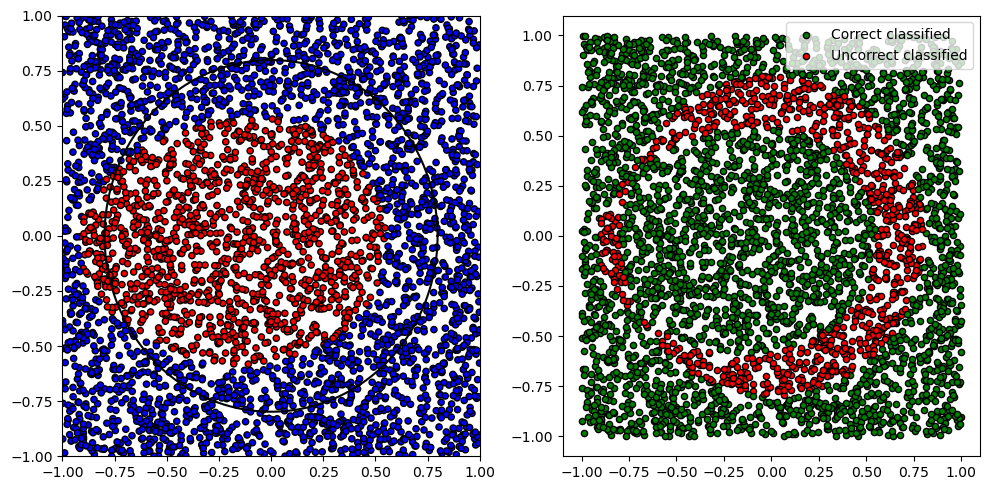

In [30]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 8 layers

In [ ]:
# 45 min
n_layers = 8
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[0.73812284 4.93648885 4.23183078]
 [0.72263503 4.3656874  2.77432344]
 [5.93751452 0.88977036 4.03904132]
 [2.40005141 6.01184388 2.07329341]
 [6.04559237 5.66420265 1.69886797]
 [5.04880189 6.25556569 1.58752846]
 [2.74435189 3.26839196 1.85310698]
 [0.09591182 1.38311283 1.77146169]] [[0.4435997  0.17110248 0.87325436]
 [0.70491113 0.08520048 0.65009245]
 [0.65365648 0.95622117 0.00302087]
 [0.24793245 0.92779148 0.93213392]
 [0.72058642 0.76576332 0.09148296]
 [0.51387583 0.23158299 0.18121804]
 [0.8103033  0.13503814 0.46865164]
 [0.93857824 0.18583206 0.97799342]] [0.99428799 0.55561715]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 70.099857
Iteration 2, cost: 63.777581
Iteration 3, cost: 56.602919
Iteration 4, cost: 51.637827
Iteration 5, cost: 49.767053
Iteration 6, cost: 48.923830
Iteration 7, cost: 46.659476
Iteration 8, cost: 44.700463
Iteration 9, cost: 42.547353
Iteration 10, cost: 41.481275
Iteration 11, cost: 39.908117
Iteration 12, cost: 38.768223
Iteration 13

In [32]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.9103


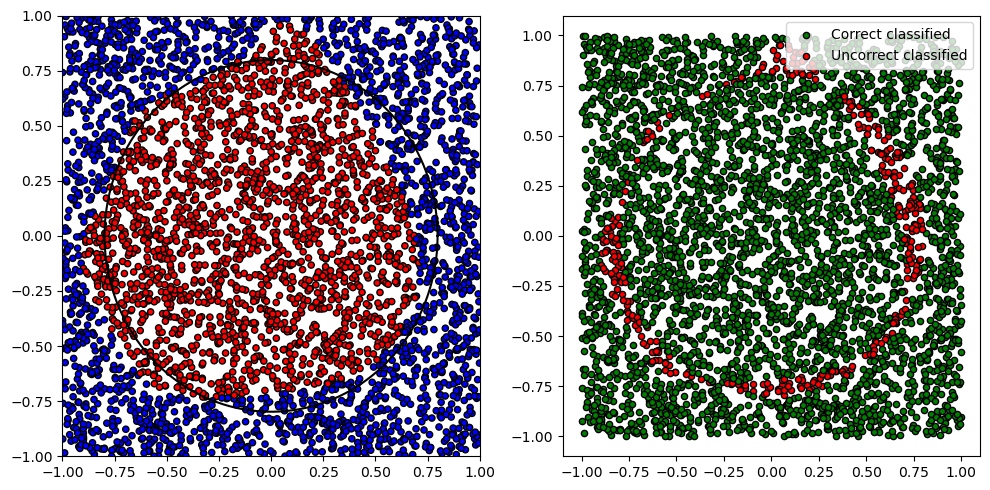

In [33]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)